# 02 - Generate Simulated Measurements

This notebook generates simulated return signals from the scatterer distributions created in `01_create_scatterer_database.ipynb` and estimates their statistical moments from the measured spectrum.

For each discrete or Gaussian-mixture scatterer:

1. construct the band-limited interrogating waveform
2. convolve the waveform with the scatter distribution
3. optionally add Gaussian noise at a specified signal-to-noise ratio (SNR)
4. estimate the scatter spectrum from the return and known interrogating spectrum
5. fit a truncated spectral Taylor expansion
6. recover the scatterer's mean, standard deviation, skewness, and kurtosis

## Measurement configuration

The simulations use a complex interrogating waveform composed of six equally-spaced spectral components spanning the normalized bandwidth $0 \le f \le B$. The signal duration is $20B^{-1}$.

Each return is normalized to unit average power before noise is added. As a result, absolute return amplitude is not used as information when estimating the scatterer moments.

The measured return spectrum $R(f)$ is related to the known interrogating spectrum $G(f)$ and scatter spectrum $H(f)$ through $R(f) = G(f)H(f)$.

The scatter spectrum is therefore estimated at the interrogating frequencies from $H(f_k)=R(f_k)/G(f_k)$. Its low-frequency Taylor coefficients are then used to estimate the first four raw moments and their corresponding standardized central moments.

## Setup

This notebook should be runnable from the repository root. The reusable analysis modules are loaded from `src/`.

## Inputs

- `delta_database.csv`
- `gmm_database.csv`

Both are generated by `01_create_scatterer_database.ipynb`.

## Outputs

Generated measurement databases are written to:

`data/returns/`

The full study generates databases for both scatterer types, six noise levels, and fourth- and sixth-order spectral fits.

> **Runtime:** Generating the complete database set is computationally expensive and may require many hours. Output is written incrementally, so interrupted calculations can be resumed.

In [16]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [18]:
ROOT        = Path.cwd()
SRC_DIR     = ROOT / "src"
DELTA_DB    = ROOT / "delta_database.csv"
GMM_DB      = ROOT / "gmm_database.csv"

if not SRC_DIR.is_dir():
    raise FileNotFoundError("Project root not found. Run this notebook with the repository "
                            "root as the current working directory.")

for database_file in [DELTA_DB, GMM_DB]:
    if not database_file.exists():
        raise FileNotFoundError(f"{database_file.name} not found. "
                                 "Run 01_create_scatterer_database.ipynb first.")

In [19]:
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import gmm
import databases as dbl
import scatterers as sfl

In [20]:
BASE_TYPE   = 'discrete'
SCATTERERS  = ['delta', 'gmm']
SNR_VALUES  = ['NA', 0, 10, 20, 30, 40]
FIT_ORDERS  = [4, 6]

## Validate the process

Before generating the full databases, test a small number of records to confirm that waveform generation, noise addition, spectral fitting, and output-column construction are working correctly

### Single configuration

In [21]:
dbconfig    = dbl.DB_Config()
dbconfig.edit_base_type(BASE_TYPE)
dbconfig.edit_scatterer_type('delta')
dbconfig.set_testing_vars(max_fit_order=6)
dbconfig.make_interrogating_wave(SignalLen=20)
dbconfig.make_feature_columns(corrs=False)
dbconfig.add_noise_vals(20)
test_chunk = dbconfig.test_one_chunk(ROOT, chunk_size=5, return_source=False, plot=False)
display(test_chunk[['mean', 'std', 'skew', 'kurtosis', 'spectral_mean_pred', 'spectral_std_pred',
                    'spectral_skew_pred', 'spectral_kurt_pred']])

Test chunk passed.
Rows tested: 5
Columns produced: 31
scatterer=delta, base_type=discrete, SignalLen=20, snr=20


,mean,std,skew,kurtosis,spectral_mean_pred,spectral_std_pred,spectral_skew_pred,spectral_kurt_pred
0,-0.051,0.258107,-0.009529,1.529783,-0.045766,0.256444,0.035222,1.354106
1,0.171,0.381234,-0.446193,1.234727,0.170217,0.379792,-0.485944,1.236156
2,-0.012,0.309218,-0.253833,1.220429,-0.009980,0.311022,-0.239389,1.312086
3,-0.255,0.256817,0.990777,2.135795,-0.250913,0.263609,1.143003,2.899118
4,0.096,0.282956,-0.911108,1.871307,0.097318,0.276679,-0.925193,1.589732


### Multiple representative configurations

In [ ]:
dbconfig    = dbl.DB_Config()
dbconfig.edit_base_type(BASE_TYPE)
dbconfig.make_interrogating_wave()

for scatterer in SCATTERERS:
    dbconfig.edit_scatterer_type(scatterer)

    for fit_order in FIT_ORDERS:
        dbconfig.set_testing_vars(max_fit_order=fit_order)

        for snr in [20, 40]:
            dbconfig.make_feature_columns(corrs=True)
            dbconfig.add_noise_vals(snr)
            test_chunk = dbconfig.test_one_chunk(ROOT, chunk_size=5, return_source=False)

            print(scatterer, fit_order, snr)
            display(test_chunk[['mean', 'std', 'skew', 'kurtosis', 'spectral_mean_pred', 'spectral_std_pred',
                                'spectral_skew_pred', 'spectral_kurt_pred']])

## Generate the full measurement databases

The following cell generates the complete set of measurement databases used in the numerical study.

For each discrete and GMM scatterer, measurements are simulated at:

- noiseless ("NA")
- 0 dB
- 10 dB
- 20 dB
- 30 dB
- 40 dB

and fitted using both fourth- and sixth-order spectral Taylor models.

The calculation is computationally expensive and may require many hours. Results are written incrementally to `data/returns/`. If a run is interrupted, rerunning the cell resumes each existing database from its current number of
records.

***Do not change the simulation configuration when resuming an existing output file.

In [ ]:
dbconfig    = dbl.DB_Config()
dbconfig.edit_base_type(BASE_TYPE)
dbconfig.make_interrogating_wave()

for scatterer in SCATTERERS:
    dbconfig.edit_scatterer_type(scatterer)

    for snr in SNR_VALUES:
        dbconfig.add_noise_vals(snr)

        for fit_order in FIT_ORDERS:
            dbconfig.set_testing_vars(max_fit_order=fit_order)
            # correlations were not used in the final paper and add time to the run
            dbconfig.make_feature_columns(corrs=False)
            dbconfig.make_database(ROOT)

## Visualize the interrogating signal

The interrogating waveform consists of six equally spaced spectral components within the normalized bandwidth. The time-domain panel shows the real part of the resulting complex waveform.

Amplitudes are scaled such that component frequencies in the spectral domain have an amplitude of 1.

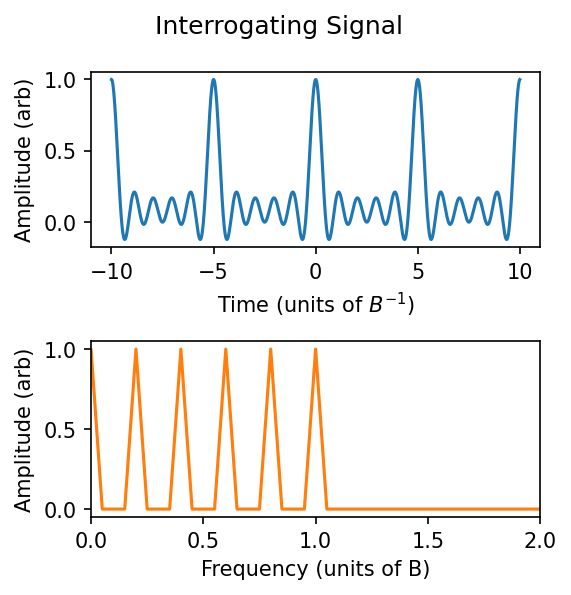

In [26]:
dbconfig    = dbl.DB_Config()

dbconfig.edit_base_type('discrete')
dbconfig.make_interrogating_wave(20)

fftsig      = np.fft.fft(dbconfig.sr.signal)
freqs       = np.fft.fftfreq(len(dbconfig.sr.t), d=dbconfig.sr.t[1] - dbconfig.sr.t[0])

plt.rcParams['figure.dpi'] = 150
fig, axs    = plt.subplots(2, 1, figsize=(4, 4))

fig.suptitle('Interrogating Signal')
axs[0].plot(dbconfig.sr.t, np.real(dbconfig.sr.signal)/np.max(np.abs(dbconfig.sr.signal)))
axs[0].set_xlabel(r'Time (units of $B^{-1}$)')
axs[0].set_ylabel('Amplitude (arb)')

axs[1].plot(np.fft.fftshift(freqs), np.fft.fftshift(np.abs(fftsig))/np.max(np.abs(fftsig)), c='tab:orange')
axs[1].set_xlim(0, 2)
axs[1].set_xlabel('Frequency (units of B)')
axs[1].set_ylabel('Amplitude (arb)')

plt.tight_layout()
plt.show()

## Compare discrete and GMM scatterers

The following example compares a discrete point-scatterer distribution with a GMM having similar low-order statistical moments.

Although the two scatter distributions can have substantially different fine-scale structure, their band-limited return waveforms can be very similar. This illustrates the central motivation for characterizing unresolved targets through low-order statistical moments rather than attempting direct reconstruction of all sub-resolution structure.

In [ ]:
moment_cols = ['mean', 'std', 'skew', 'kurtosis']
delta_db    = pd.read_csv(DELTA_DB)
gmm_db      = pd.read_csv(GMM_DB)

In [ ]:
# exact scatterers used in the paper visualization. finds the record in the GMM database whose moments
# match those of the target record in the Delta database. since locations and amplitudes of the original
# delta scatterers are preserved in the GMM database, we simply look for the matching values to indicate
# the corresponding GMM record.
delta_row   = delta_db.iloc[124637]
source_cols = ['loc_1', 'loc_2', 'loc_3', 'amp_1', 'amp_2', 'amp_3']
matched     = np.ones(len(gmm_db), dtype=bool)

for col in source_cols:
    matched &= np.isclose(gmm_db[col], delta_row[col])

gmm_row     = gmm_db[matched].iloc[0]

'''
Optional exploration:
To visualize any other scatterer, instead use the code below. Constraints are set to show scatterers with
appreciably large extent relative to the interrogating wave's inverse bandwidth, to show that low-order scatterer
moments largely control the shape of the return signal, regardless of specific scatterer morphology,
even when the scatterer's extent is reasonably "large".
'''
# delta_row   = delta_db[(delta_db['std'] > 0.25) & (np.abs(delta_db['skew']) < .5)].sample(1).iloc[0]
# diff        = gmm_db[moment_cols].values - delta_row[moment_cols].values
# gmm_row     = gmm_db.iloc[np.argmin(np.linalg.norm(diff, axis=1))]

In [ ]:
# print scatterer moment parameters
print(delta_row[moment_cols])
print('')
print(gmm_row[moment_cols])

mean       -0.134000
std         0.285174
skew        0.273098
kurtosis    1.641196
Name: 124637, dtype: float64

mean          -0.134
std         0.285153
skew        0.273143
kurtosis    1.641213
Name: 105651, dtype: object


### Compare distributions, spectra, and returns

In [ ]:
dbconfig        = dbl.DB_Config()

dbconfig.edit_base_type('discrete')
dbconfig.make_interrogating_wave(20)

base            = dbconfig.sr
fftsig          = np.fft.fftshift(np.fft.fft(base.signal))
freqs           = np.fft.fftshift(np.fft.fftfreq(len(base.t), d=base.t[1] - base.t[0]))
d_scatter       = sfl.Delta(dbconfig.sr.t, loc1=delta_row['loc_1'], loc2=delta_row['loc_2'], loc3=delta_row['loc_3'],
                            amp1=delta_row['amp_1'], amp2=delta_row['amp_2'], amp3=delta_row['amp_3']).scatter
g_scatter       = gmm.gmm_pdf(base.t, [gmm_row['mu1'], gmm_row['mu2'], gmm_row['sigma'], gmm_row['w1']])
g_fft           = np.fft.fftshift(np.fft.fft(g_scatter))
d_fft           = np.fft.fftshift(np.fft.fft(d_scatter))
delta_return    = base.create_return_wave(d_scatter, add_noise=False, real=False)
gmm_return      = base.create_return_wave(g_scatter, add_noise=False, real=False)

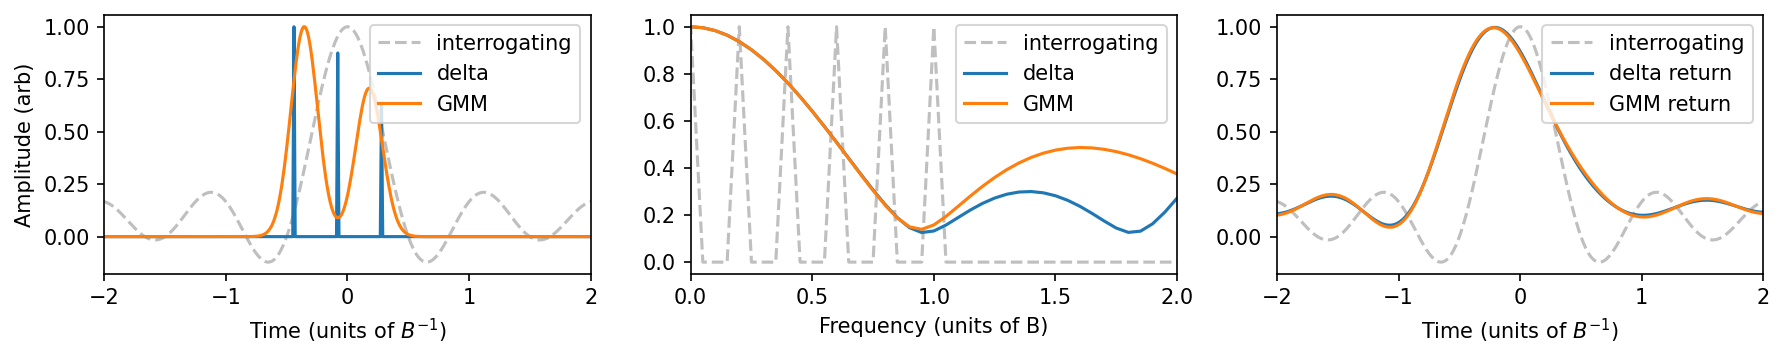

In [ ]:
plt.rcParams['figure.dpi'] = 150
fig, axs = plt.subplots(1, 3, figsize=(12, 2.5))

axs[0].plot(base.t, np.real(base.signal)/np.max(np.abs(base.signal)), label='interrogating', alpha=0.5, c='gray', ls='--')
axs[0].plot(base.t, np.real(d_scatter)/np.max(np.abs(d_scatter)), label='delta')
axs[0].plot(base.t, np.real(g_scatter)/np.max(np.abs(g_scatter)), label='GMM')

axs[1].plot(freqs, np.abs(fftsig)/np.max(np.abs(fftsig)), label='interrogating', alpha=0.5, c='gray', ls='--')
axs[1].plot(freqs, np.abs(d_fft)/np.max(np.abs(d_fft)), label='delta')
axs[1].plot(freqs, np.abs(g_fft)/np.max(np.abs(g_fft)), label='GMM')

axs[2].plot(base.t, np.real(base.signal)/np.max(np.abs(base.signal)), label='interrogating', alpha=0.5, c='gray', ls='--')
axs[2].plot(base.t, np.real(delta_return)/np.max(np.abs(delta_return)), label='delta return')
axs[2].plot(base.t, np.real(gmm_return)/np.max(np.abs(gmm_return)), label='GMM return')

axs[0].legend()
axs[1].legend()
axs[2].legend()

axs[0].set_xlim(-2, 2)
axs[1].set_xlim(0, 2)
axs[2].set_xlim(-2, 2)

axs[0].set_ylabel('Amplitude (arb)')
axs[0].set_xlabel('Time (units of $B^{-1}$)')
axs[1].set_xlabel('Frequency (units of B)')
axs[2].set_xlabel('Time (units of $B^{-1}$)')

plt.tight_layout()
plt.show()